In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#reading the dataframe last cleaned dataframe as df_master

In [3]:
df_master = pd.read_csv(r"../data/cleaned/df_master_cleaned.csv")

df_master

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,max_installments,primary_payment_type,payment_sequential,avg_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,cool_stuff,27277,volta redonda,SP,72.19,2.0,credit_card,1.0,5.0,1.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,pet_shop,3471,sao paulo,SP,259.83,3.0,credit_card,1.0,4.0,1.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,furniture_decor,37564,borda da mata,MG,216.87,5.0,credit_card,1.0,5.0,1.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,perfumery,14403,franca,SP,25.78,2.0,credit_card,1.0,4.0,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,garden_tools,87900,loanda,PR,218.04,3.0,credit_card,1.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,housewares,88303,itajai,SC,343.40,1.0,boleto,1.0,5.0,1.0
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,computers_accessories,1206,sao paulo,SP,386.53,1.0,boleto,1.0,5.0,1.0
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,sports_leisure,80610,curitiba,PR,116.85,3.0,credit_card,1.0,5.0,1.0
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,computers_accessories,4733,sao paulo,SP,64.71,3.0,credit_card,1.0,5.0,1.0


In [4]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

df_master[date_columns] = df_master[date_columns].apply(pd.to_datetime)

In [5]:
#changing the datatype to col to the date columns

In [6]:
#adding new col delvery time day by deliver date - purchase from order made to cust

In [7]:
#delivery time added
df_master['delivery_time_days'] = (
    df_master["order_delivered_customer_date"]
    - df_master["order_purchase_timestamp"]
).dt.days

In [8]:
#add new col shipping duration by minus carrire date from delivered customer date shiiping from wharehouse to cust

In [9]:
#shipping duration

df_master['shipping_duration_days'] = (
    df_master['order_delivered_customer_date']
    - df_master['order_delivered_carrier_date']
).dt.days

In [10]:
#adding new col to find how many days to find the ooder processing how many days to confrimthe order

In [11]:
#order processing col
df_master['order_processing_time_days'] = (
    df_master['order_approved_at']
    - df_master['order_purchase_timestamp']
).dt.days

In [12]:
## Total Order Value

#A new feature named **total_order_value** was created by adding the product price and freight cost.

#**Total Order Value = Price + Freight Value**

In [13]:
# Total Order Value
df_master['total_order_value'] = (
    df_master['price'] + df_master['freight_value']
)


In [14]:
#creating new col avg product by mean of the price by pro id

In [15]:
#avg product price

avg_product_price = (
    df_master.groupby('product_id')['price'].mean().reset_index()
)

avg_product_price.rename(columns={'price': 'average_product_price'},inplace=True)

df_master = df_master.merge(avg_product_price,on='product_id',how='left')

df_master[['product_id', 'price', 'average_product_price']].head()

,product_id,price,average_product_price
0,4244733e06e7ecb4970a6e2683c13e61,58.90,59.233333
1,e5f2d52b802189ee658865ca93d83a8f,239.90,239.900000
2,c777355d18b72b67abbeef9df44fd0fd,199.00,199.000000
3,7634da152a4610f1595efa32f14722fc,12.99,12.990000
4,ac6c3623068f30de03045865e4e10089,199.90,202.627273


In [16]:
#new col purchas count by cust id and order id uniq

In [17]:
#customer purchase count

customer_purchase_count = (df_master.groupby('customer_unique_id')['order_id'].nunique().reset_index())

customer_purchase_count.rename(columns={'order_id': 'customer_purchase_count'},inplace=True)

df_master = df_master.merge(
    customer_purchase_count,
    on='customer_unique_id',
    how='left')

df_master

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,primary_payment_type,payment_sequential,avg_review_score,review_count,delivery_time_days,shipping_duration_days,order_processing_time_days,total_order_value,average_product_price,customer_purchase_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,credit_card,1.0,5.0,1.0,7,1,0,72.19,59.233333,1
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,credit_card,1.0,4.0,1.0,16,8,0,259.83,239.900000,2
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,credit_card,1.0,5.0,1.0,7,6,0,216.87,199.000000,1
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,credit_card,1.0,4.0,1.0,6,4,0,25.78,12.990000,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,credit_card,1.0,5.0,1.0,25,13,0,218.04,202.627273,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,boleto,1.0,5.0,1.0,17,15,1,343.40,291.185319,1
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,boleto,1.0,5.0,1.0,9,6,2,386.53,355.000000,1
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,credit_card,1.0,5.0,1.0,4,1,1,116.85,93.157143,1
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,credit_card,1.0,5.0,1.0,1,1,0,64.71,55.899091,1


In [18]:
"""df_master.drop(columns=['customer_purchase_count_y'], inplace=True)

df_master.rename(
    columns={'customer_purchase_count_x': 'customer_purchase_count'},
    inplace=True
)"""

"df_master.drop(columns=['customer_purchase_count_y'], inplace=True)\n\ndf_master.rename(\n    columns={'customer_purchase_count_x': 'customer_purchase_count'},\n    inplace=True\n)"

In [19]:
df_master

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,primary_payment_type,payment_sequential,avg_review_score,review_count,delivery_time_days,shipping_duration_days,order_processing_time_days,total_order_value,average_product_price,customer_purchase_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,credit_card,1.0,5.0,1.0,7,1,0,72.19,59.233333,1
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,credit_card,1.0,4.0,1.0,16,8,0,259.83,239.900000,2
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,credit_card,1.0,5.0,1.0,7,6,0,216.87,199.000000,1
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,credit_card,1.0,4.0,1.0,6,4,0,25.78,12.990000,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,credit_card,1.0,5.0,1.0,25,13,0,218.04,202.627273,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,boleto,1.0,5.0,1.0,17,15,1,343.40,291.185319,1
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,boleto,1.0,5.0,1.0,9,6,2,386.53,355.000000,1
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,credit_card,1.0,5.0,1.0,4,1,1,116.85,93.157143,1
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,credit_card,1.0,5.0,1.0,1,1,0,64.71,55.899091,1


In [20]:
#by the cust purchase count we calc the repat cust if 1 he is repaet cust no one time

In [21]:
#repeat customer
df_master['repeat_customer_indicator'] = (
    df_master['customer_purchase_count'] > 1
).astype(int)

In [22]:
df_master

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,payment_sequential,avg_review_score,review_count,delivery_time_days,shipping_duration_days,order_processing_time_days,total_order_value,average_product_price,customer_purchase_count,repeat_customer_indicator
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,1.0,5.0,1.0,7,1,0,72.19,59.233333,1,0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,1.0,4.0,1.0,16,8,0,259.83,239.900000,2,1
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,1.0,5.0,1.0,7,6,0,216.87,199.000000,1,0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,1.0,4.0,1.0,6,4,0,25.78,12.990000,1,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,1.0,5.0,1.0,25,13,0,218.04,202.627273,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,1.0,5.0,1.0,17,15,1,343.40,291.185319,1,0
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,1.0,5.0,1.0,9,6,2,386.53,355.000000,1,0
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,1.0,5.0,1.0,4,1,1,116.85,93.157143,1,0
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,1.0,5.0,1.0,1,1,0,64.71,55.899091,1,0


In [23]:
## Revenue per Customer
"""
Revenue per customer was calculated by summing the total payment value for all orders placed by each customer.

This feature helps identify high-value customers and supports customer segmentation based on total spending."""

'\nRevenue per customer was calculated by summing the total payment value for all orders placed by each customer.\n\nThis feature helps identify high-value customers and supports customer segmentation based on total spending.'

In [24]:
#revenue per coustomer

customer_revenue = (df_master.groupby('customer_unique_id')['total_payment_value'].sum().reset_index())

customer_revenue.rename(columns={'total_payment_value': 'revenue_per_customer'},inplace=True)

df_master = df_master.merge(
    customer_revenue,
    on='customer_unique_id',
    how='left'
)

In [25]:
df_master

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,avg_review_score,review_count,delivery_time_days,shipping_duration_days,order_processing_time_days,total_order_value,average_product_price,customer_purchase_count,repeat_customer_indicator,revenue_per_customer
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,5.0,1.0,7,1,0,72.19,59.233333,1,0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,4.0,1.0,16,8,0,259.83,239.900000,2,1,284.56
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,5.0,1.0,7,6,0,216.87,199.000000,1,0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,4.0,1.0,6,4,0,25.78,12.990000,1,0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,5.0,1.0,25,13,0,218.04,202.627273,1,0,218.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,5.0,1.0,17,15,1,343.40,291.185319,1,0,343.40
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,5.0,1.0,9,6,2,386.53,355.000000,1,0,386.53
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,5.0,1.0,4,1,1,116.85,93.157143,1,0,116.85
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,5.0,1.0,1,1,0,64.71,55.899091,1,0,64.71


In [26]:
df_master['order_purchase_timestamp'].dtypes

dtype('<M8[us]')

In [27]:
#created new col called sales month upto yr and month using dt.to_period
#another col monthly sales is sum tot pay val

In [28]:
#monthly sales
df_master['sales_month'] = (df_master['order_purchase_timestamp'].dt.to_period('M').astype(str))

monthly_sales = (df_master.groupby('sales_month')['total_payment_value'].sum().reset_index())

monthly_sales.rename(columns={'total_payment_value': 'monthly_sales'},inplace=True)

df_master = df_master.merge(monthly_sales,on='sales_month',how='left')

In [29]:
df_master

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,delivery_time_days,shipping_duration_days,order_processing_time_days,total_order_value,average_product_price,customer_purchase_count,repeat_customer_indicator,revenue_per_customer,sales_month,monthly_sales
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,7,1,0,72.19,59.233333,1,0,72.19,2017-09,996279.59
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,16,8,0,259.83,239.900000,2,1,284.56,2017-04,456108.32
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,7,6,0,216.87,199.000000,1,0,216.87,2018-01,1374064.02
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,6,4,0,25.78,12.990000,1,0,25.78,2018-08,1211240.09
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,25,13,0,218.04,202.627273,1,0,218.04,2017-02,323815.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,17,15,1,343.40,291.185319,1,0,343.40,2018-04,1466607.15
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,9,6,2,386.53,355.000000,1,0,386.53,2018-07,1306707.42
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,4,1,1,116.85,93.157143,1,0,116.85,2017-10,998609.62
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,1,1,0,64.71,55.899091,1,0,64.71,2017-08,842689.94


In [30]:
## Customer Lifetime Value (CLV)
"""
Customer Lifetime Value was calculated as the total payment value generated by each customer across all completed purchases in the dataset.

This feature helps identify high-value customers and supports customer segmentation and retention analysis."""

'\nCustomer Lifetime Value was calculated as the total payment value generated by each customer across all completed purchases in the dataset.\n\nThis feature helps identify high-value customers and supports customer segmentation and retention analysis.'

In [31]:
#customer life time value
customer_clv = (df_master.groupby('customer_unique_id')['total_payment_value'].sum().reset_index())

customer_clv.rename(columns={'total_payment_value': 'customer_lifetime_value'},inplace=True)

df_master = df_master.merge(
    customer_clv,
    on='customer_unique_id',
    how='left'
)



In [32]:
#created the seller perfoemcae to calc the seller details
#by using the seller id calc the sum of tot pay as the revenue of seller 
#in same method calc the mean avg review scoe for the seller 
#revenue score by the seller reverue by max revenue in col
#same by revire
#performnece 70% reveue import 30%score 
#seller performence = seller id and score
#merge it

In [33]:
#seller performance

seller_performance = (
    df_master.groupby('seller_id').agg(
        seller_revenue=('total_payment_value', 'sum'),
        seller_avg_review=('avg_review_score', 'mean')
    ).reset_index()
)

seller_performance['revenue_score'] = (seller_performance['seller_revenue']/
                                       seller_performance['seller_revenue'].max()
)

seller_performance['review_score'] = (seller_performance['seller_avg_review']/ 
                                      seller_performance['seller_avg_review'].max()
)

seller_performance['seller_performance_score'] = (seller_performance['revenue_score'] * 0.7 + 
                                                  seller_performance['review_score'] * 0.3)

seller_performance = seller_performance[['seller_id', 'seller_performance_score']]

df_master = df_master.merge(seller_performance,on='seller_id',how='left')



In [34]:
df_master

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,order_processing_time_days,total_order_value,average_product_price,customer_purchase_count,repeat_customer_indicator,revenue_per_customer,sales_month,monthly_sales,customer_lifetime_value,seller_performance_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,0,72.19,59.233333,1,0,72.19,2017-09,996279.59,72.19,0.272003
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,0,259.83,239.900000,2,1,284.56,2017-04,456108.32,284.56,0.247390
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,0,216.87,199.000000,1,0,216.87,2018-01,1374064.02,216.87,0.235706
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,0,25.78,12.990000,1,0,25.78,2018-08,1211240.09,25.78,0.228540
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,0,218.04,202.627273,1,0,218.04,2017-02,323815.95,218.04,0.241316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,1,343.40,291.185319,1,0,343.40,2018-04,1466607.15,343.40,0.279741
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,2,386.53,355.000000,1,0,386.53,2018-07,1306707.42,386.53,0.258532
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,1,116.85,93.157143,1,0,116.85,2017-10,998609.62,116.85,0.347184
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,0,64.71,55.899091,1,0,64.71,2017-08,842689.94,64.71,0.308108


In [35]:
len(df_master.columns)

50

In [36]:
df_master.to_csv(
    r"../data/cleaned/df_master_feature_engineered.csv",
    index=False
)

In [37]:
#visualization

In [38]:
#selecting the column to corelations heat map

correlation_columns = ['price','freight_value','delivery_time_days','shipping_duration_days','order_processing_time_days',
    'total_order_value','average_product_price','customer_purchase_count','repeat_customer_indicator','revenue_per_customer',
    'monthly_sales','customer_lifetime_value','seller_performance_score','avg_review_score']

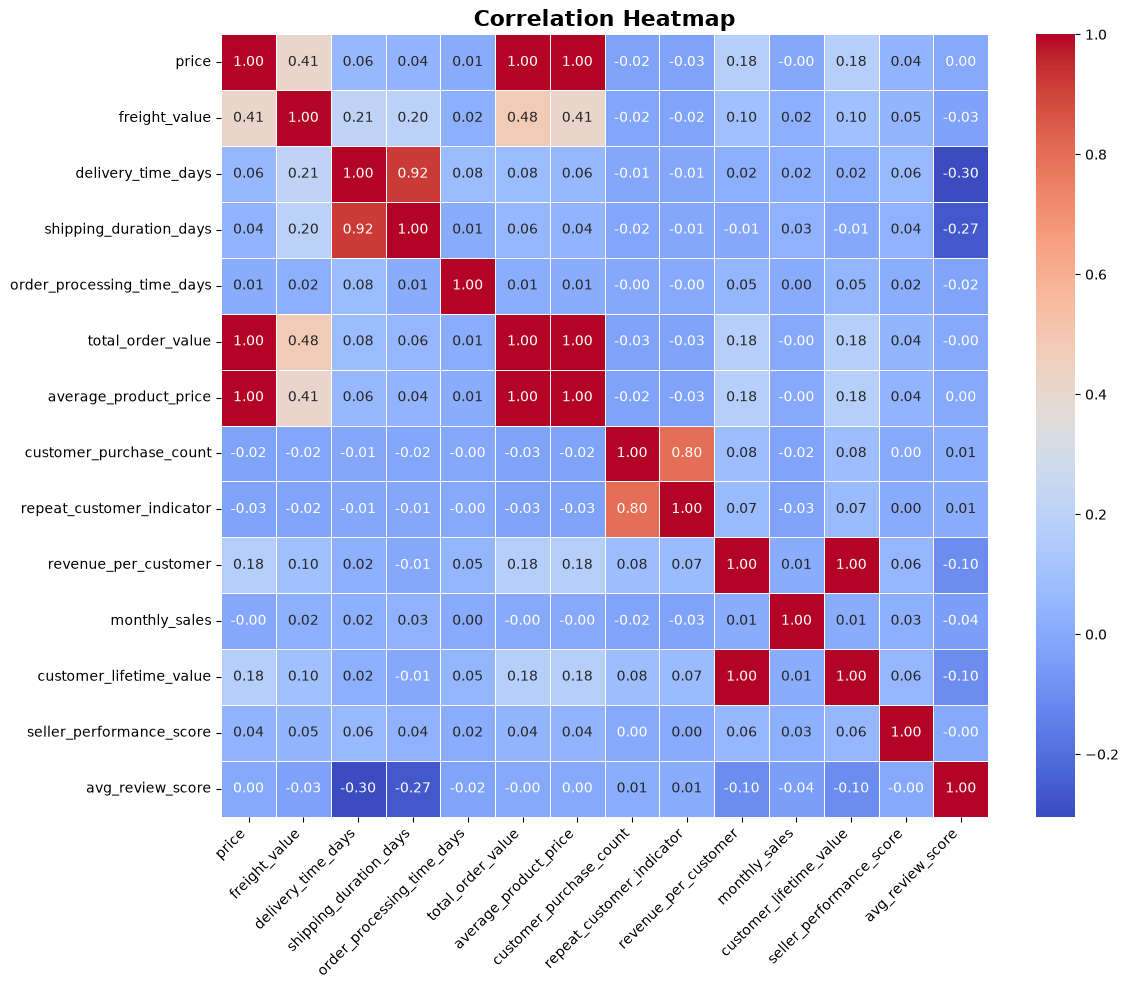

In [39]:
#correlated heat map

corr_matrix = df_master[correlation_columns].corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)

plt.title("Correlation Heatmap",fontsize=16,fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [40]:
#to understand the ditribution of newly created columns 

distribution_features = [
    'delivery_time_days',
    'shipping_duration_days',
    'order_processing_time_days',
    'total_order_value',
    'average_product_price',
    'customer_purchase_count',
    'customer_lifetime_value',
    'seller_performance_score'
]

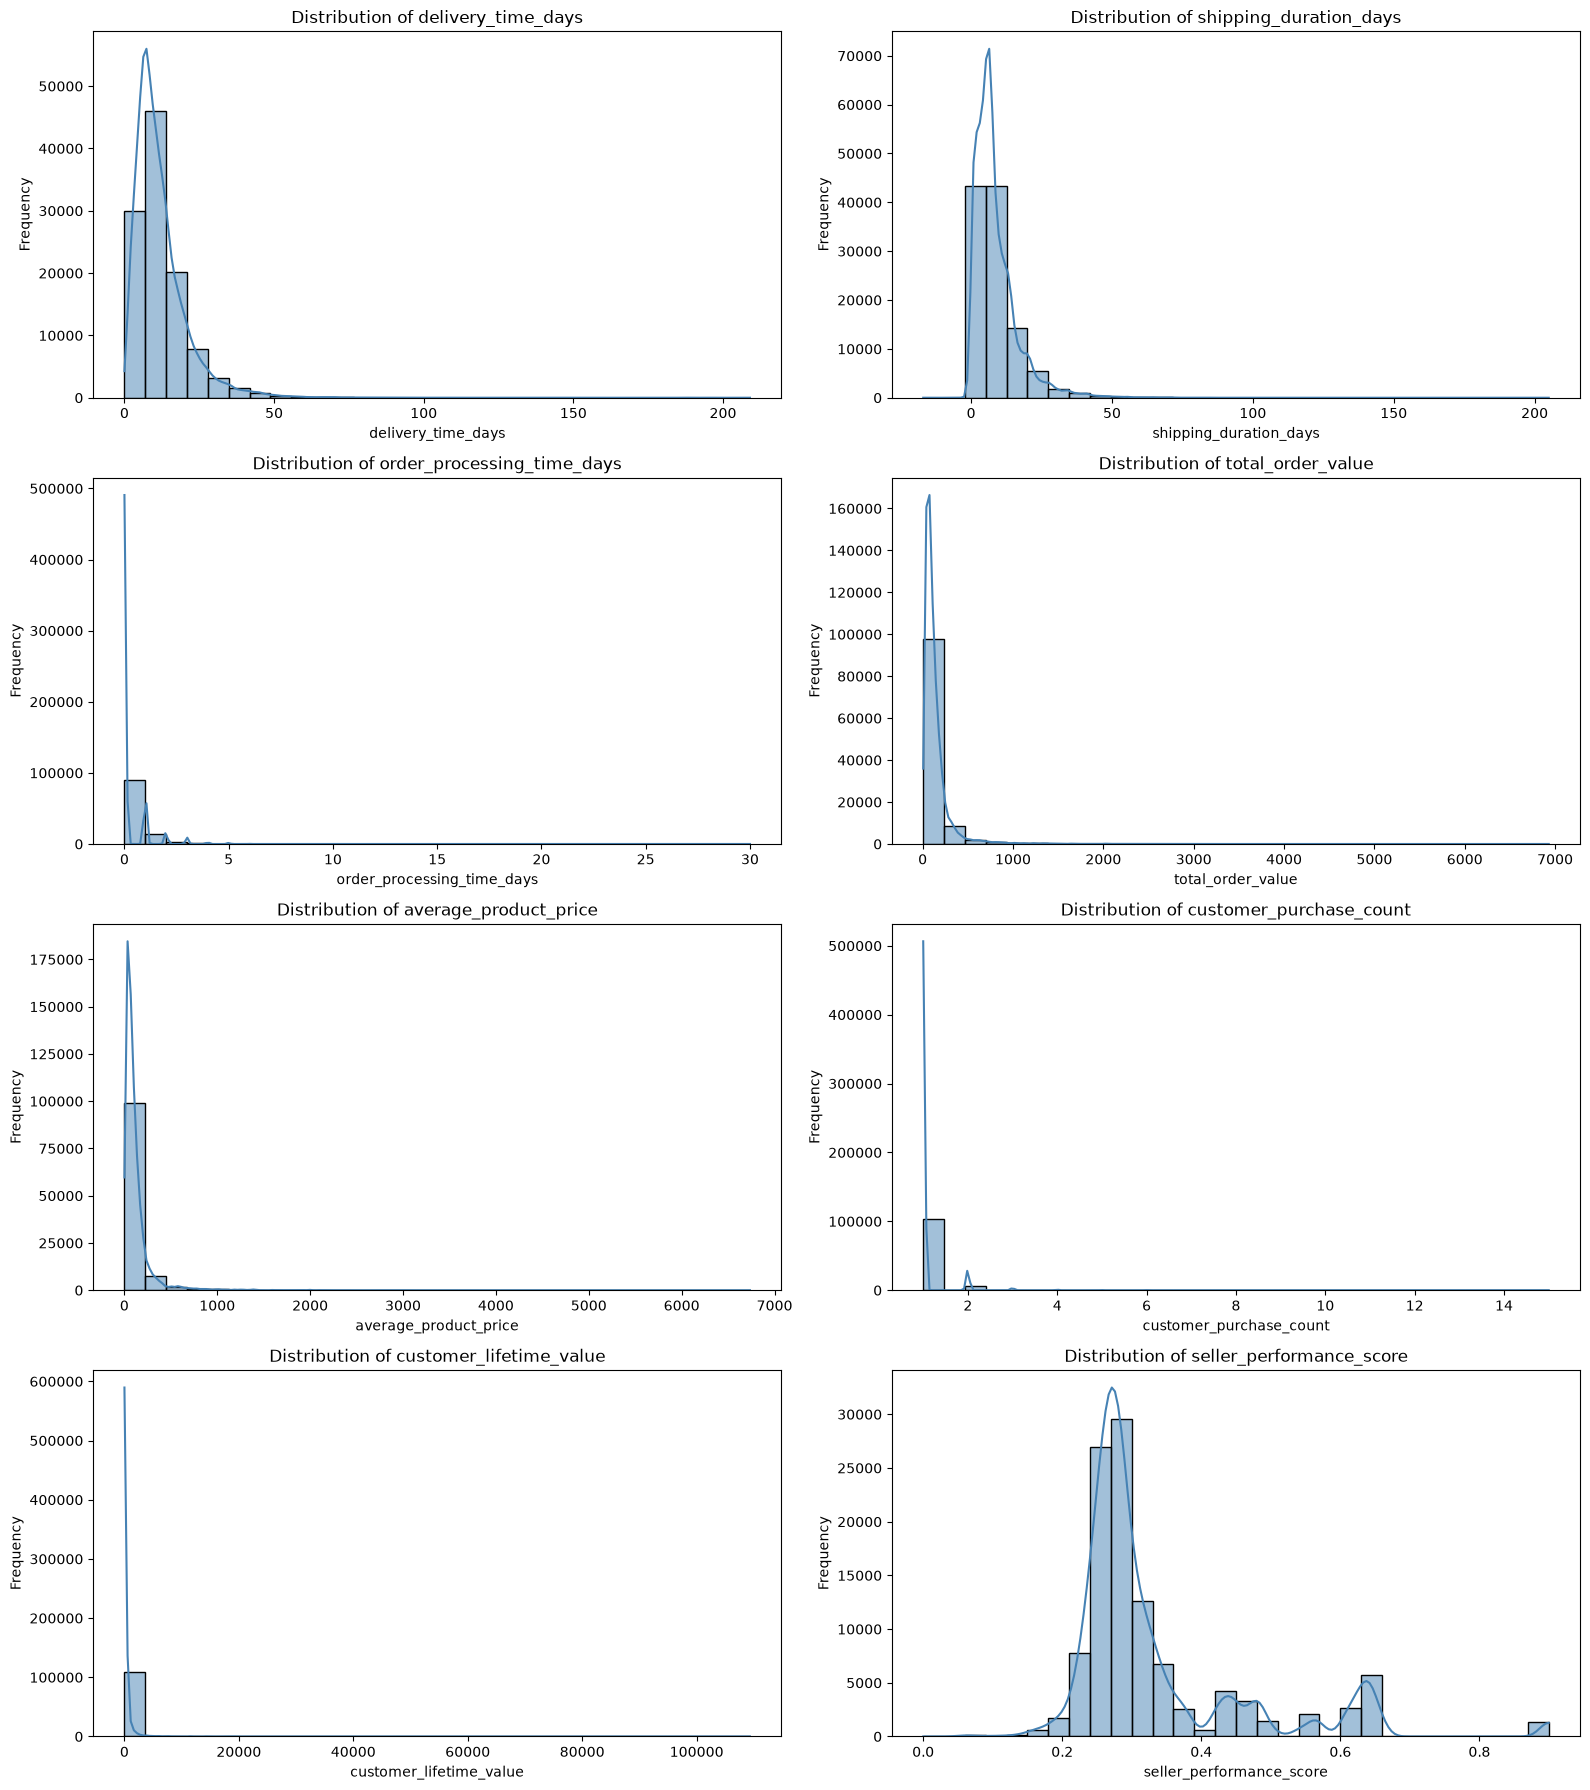

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 18))

for i, feature in enumerate(distribution_features, 1):
    plt.subplot(4, 2, i)

    sns.histplot(data=df_master,x=feature,bins=30,kde=True,color='steelblue'
    )

    plt.title(f'Distribution of {feature}', fontsize=12)
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

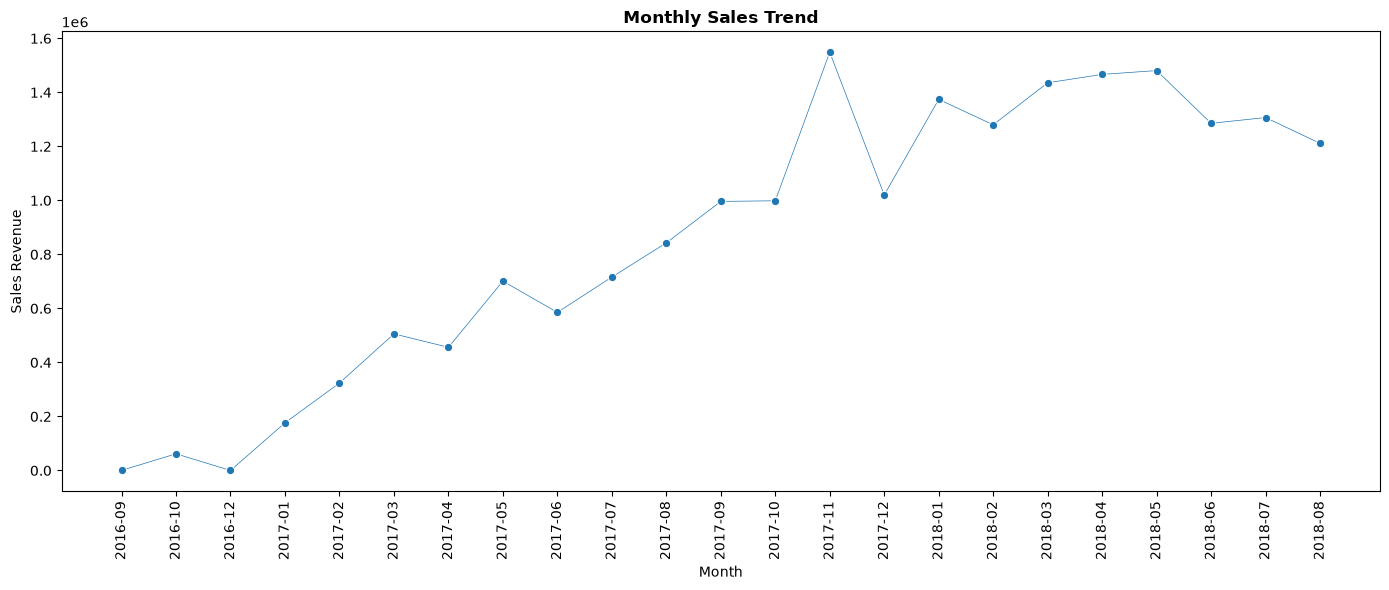

In [42]:
monthly_trend = (df_master.groupby('sales_month')['monthly_sales'].first().reset_index())

monthly_trend = monthly_trend.sort_values('sales_month')

plt.figure(figsize=(14,6))

sns.lineplot(data=monthly_trend,x='sales_month',y='monthly_sales',marker='o',linewidth=0.5)

plt.title("Monthly Sales Trend", fontsize=12, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales Revenue")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [43]:
# Phase 3 Summary

"""In this phase, multiple business-oriented features were engineered from the cleaned dataset to support advanced analytics.

### Features Created
- Delivery Time
- Shipping Duration
- Order Processing Time
- Total Order Value
- Average Product Price
- Customer Purchase Count
- Repeat Customer Indicator
- Revenue per Customer
- Monthly Sales
- Customer Lifetime Value
- Seller Performance Score

Additionally, visualization techniques including a correlation heatmap, feature distribution plots, and monthly sales trend analysis were performed to understand relationships and patterns in the engineered data.

The feature-engineered dataset was exported for use in Exploratory Data Analysis (Phase 4) and the Flask analytics dashboard."""

'In this phase, multiple business-oriented features were engineered from the cleaned dataset to support advanced analytics.\n\n### Features Created\n- Delivery Time\n- Shipping Duration\n- Order Processing Time\n- Total Order Value\n- Average Product Price\n- Customer Purchase Count\n- Repeat Customer Indicator\n- Revenue per Customer\n- Monthly Sales\n- Customer Lifetime Value\n- Seller Performance Score\n\nAdditionally, visualization techniques including a correlation heatmap, feature distribution plots, and monthly sales trend analysis were performed to understand relationships and patterns in the engineered data.\n\nThe feature-engineered dataset was exported for use in Exploratory Data Analysis (Phase 4) and the Flask analytics dashboard.'

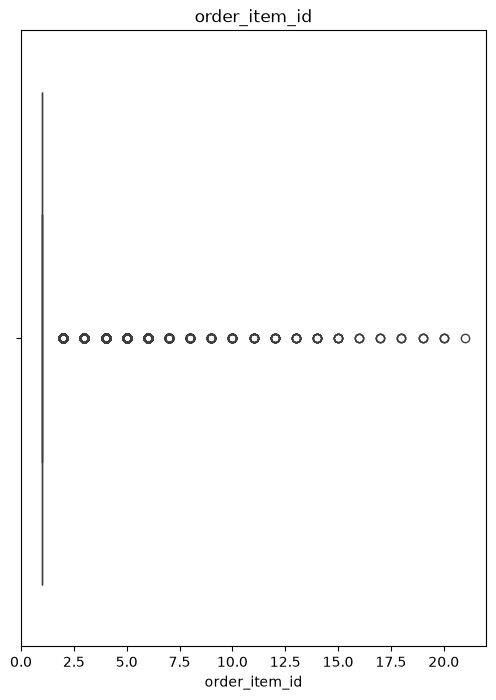

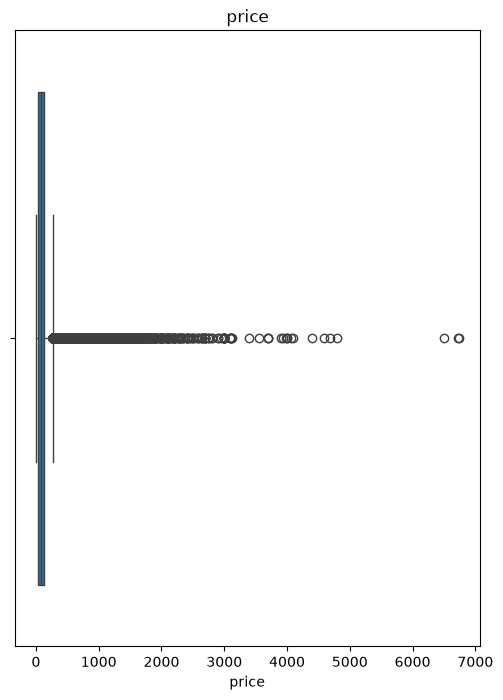

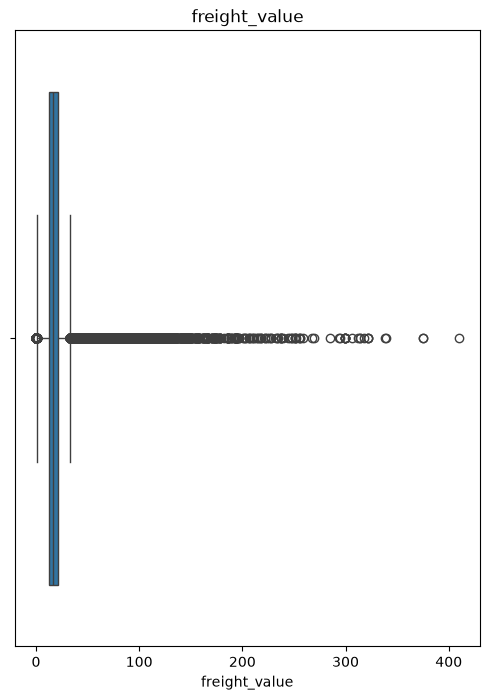

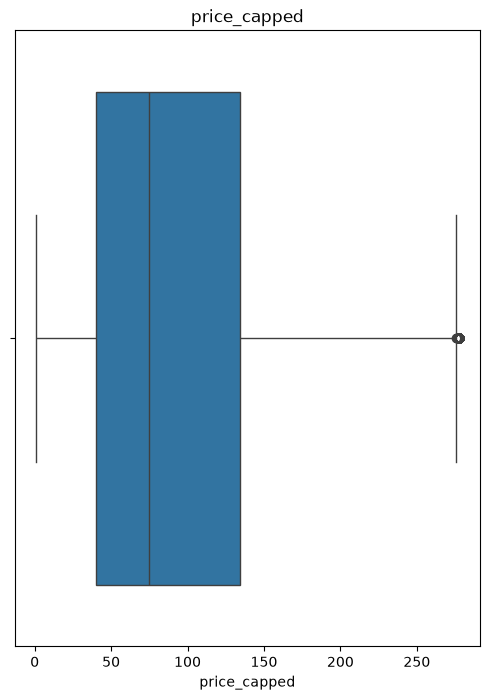

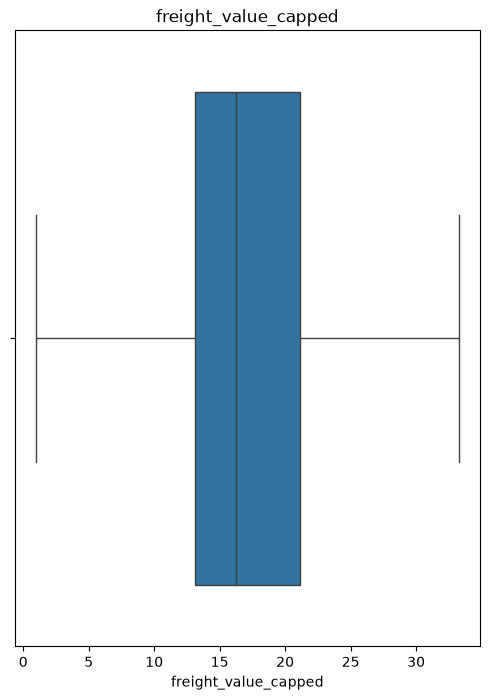

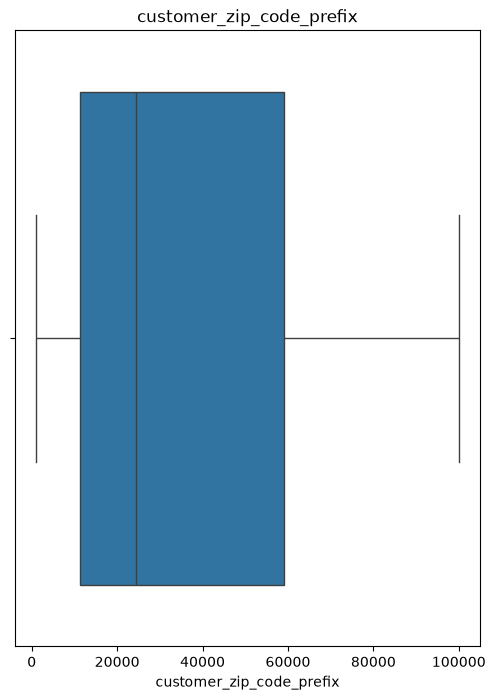

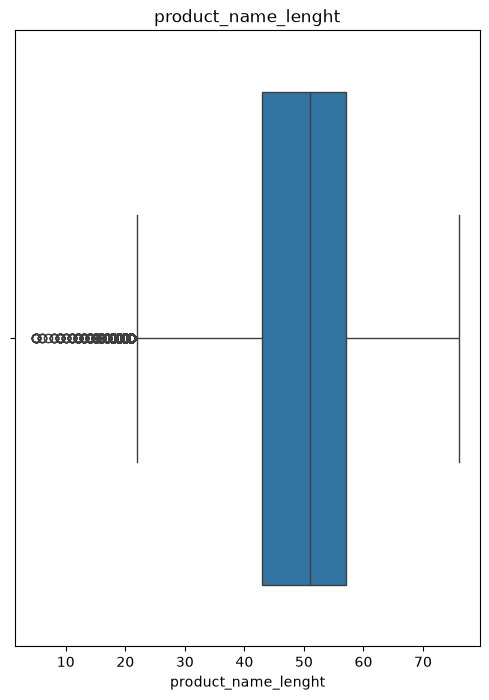

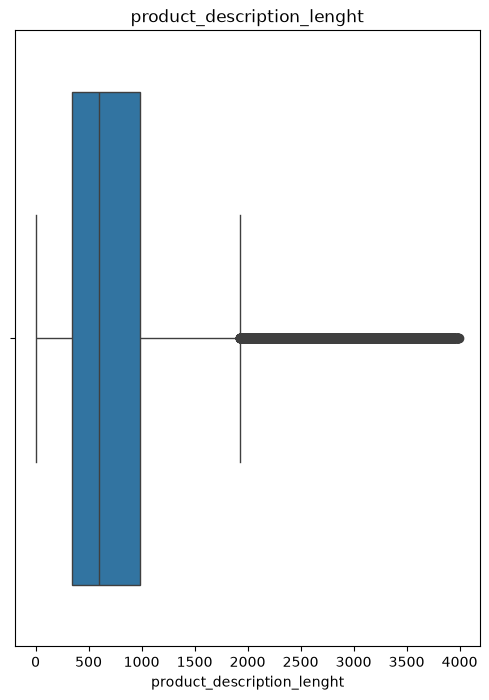

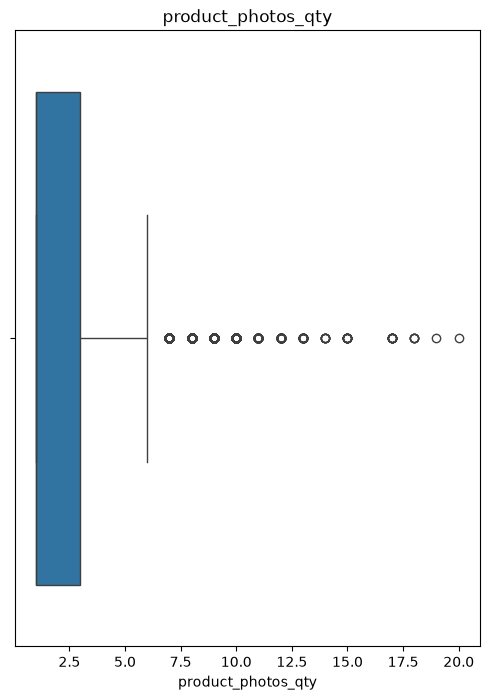

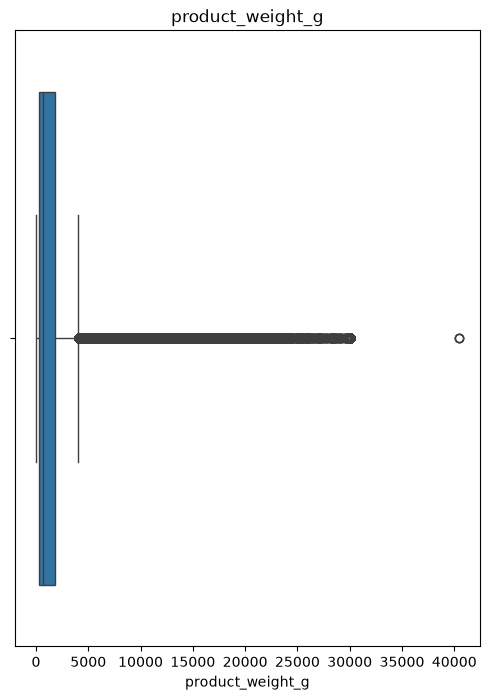

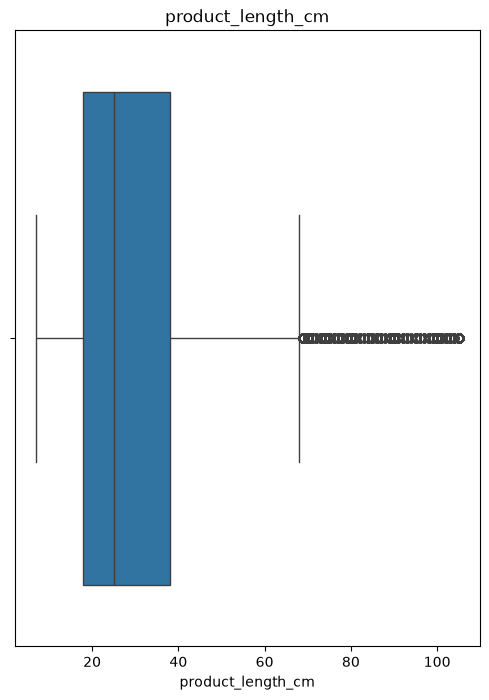

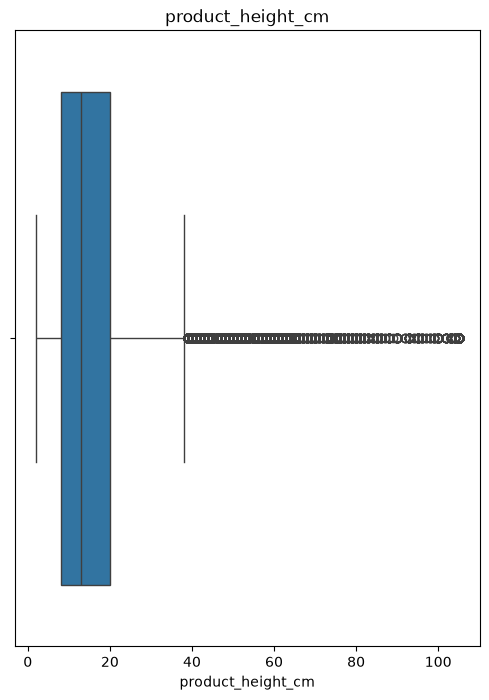

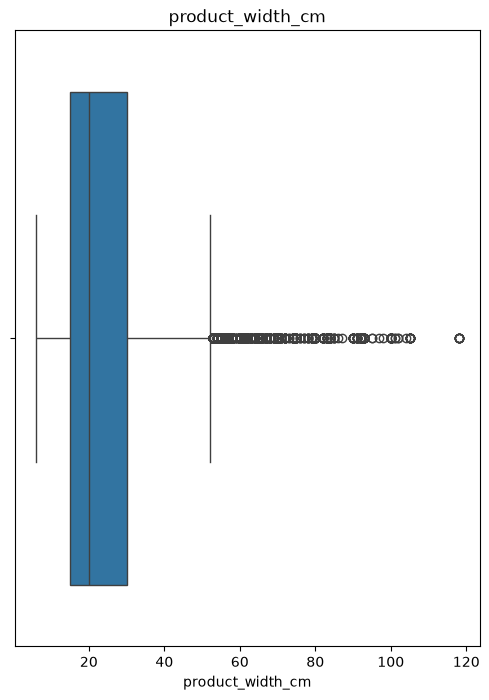

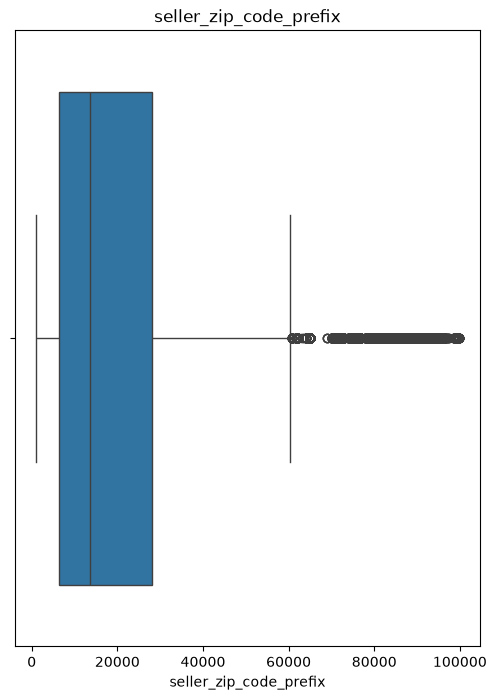

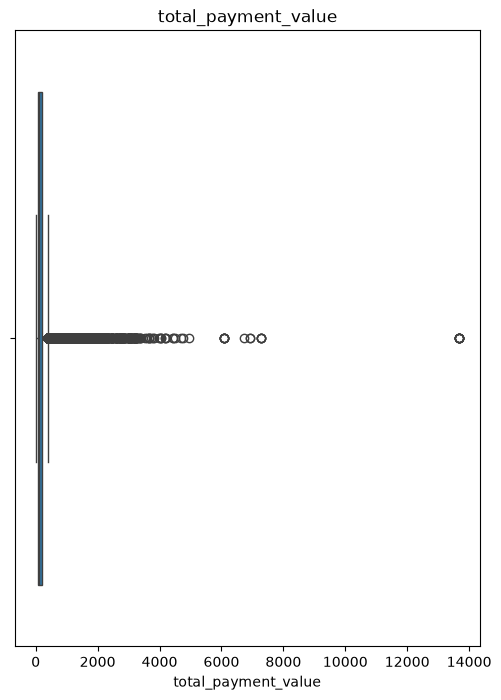

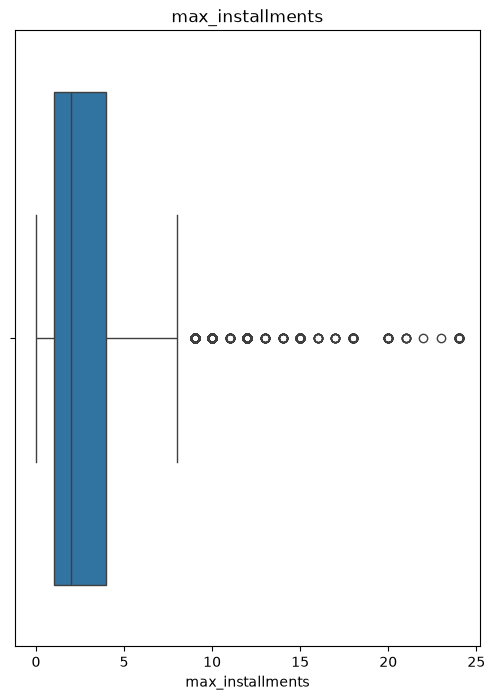

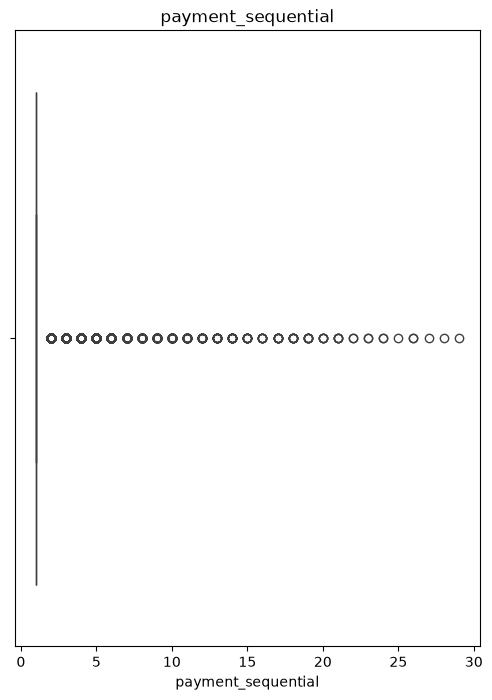

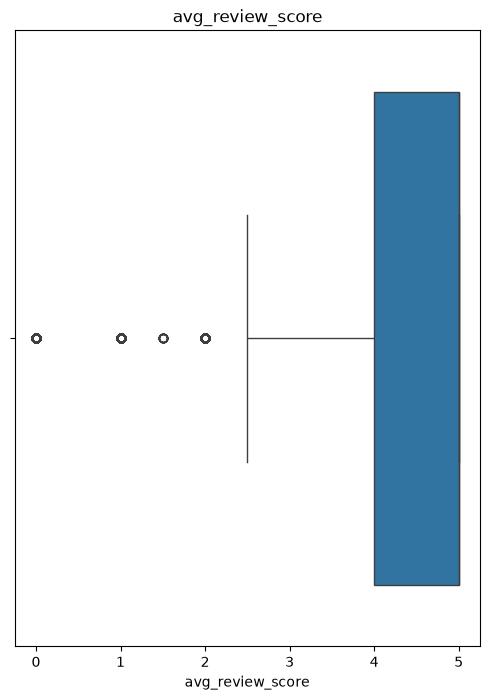

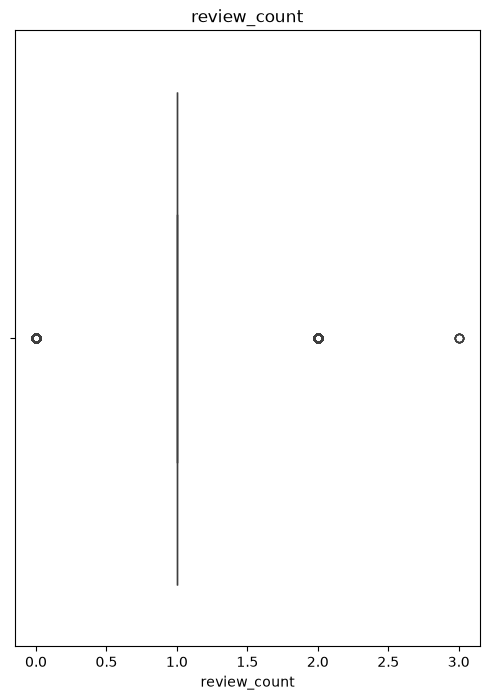

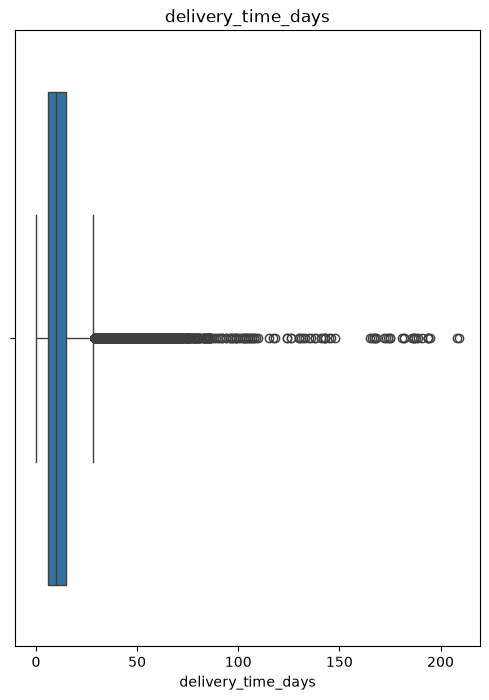

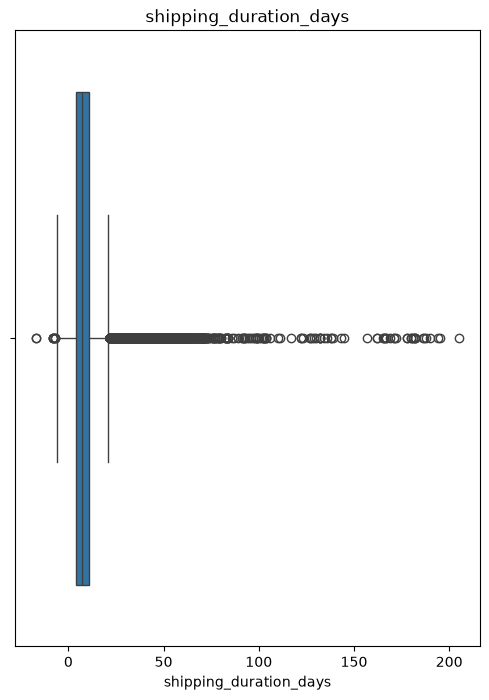

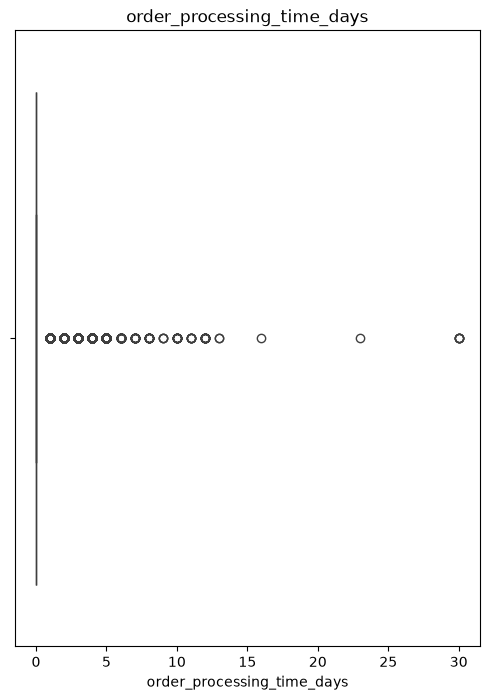

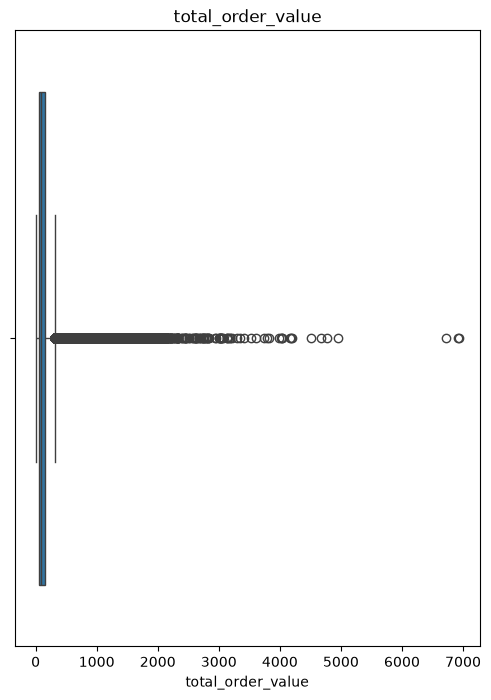

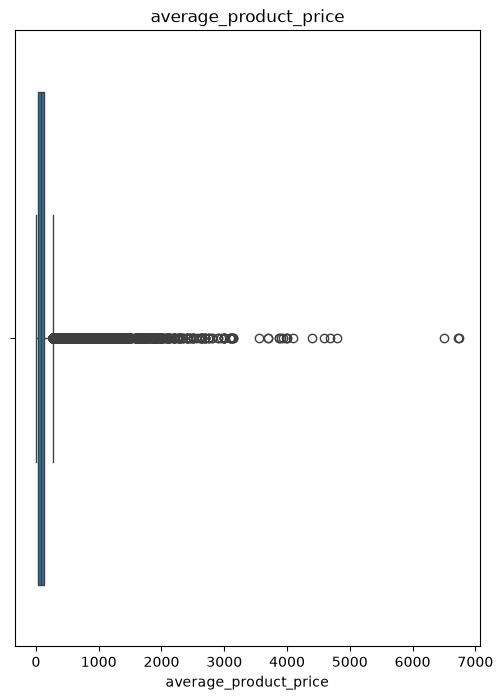

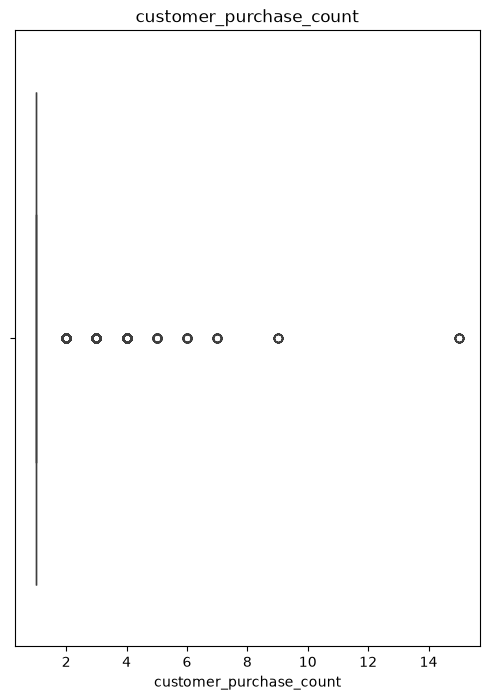

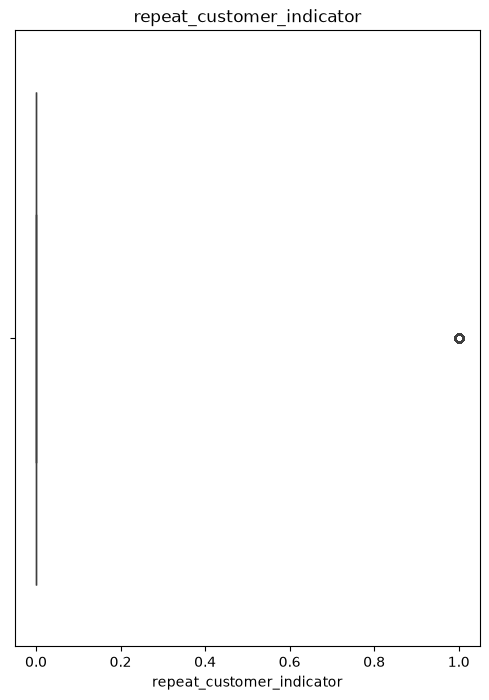

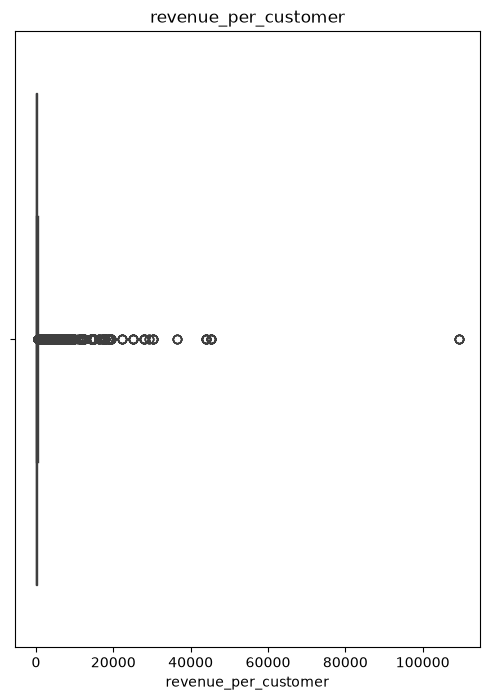

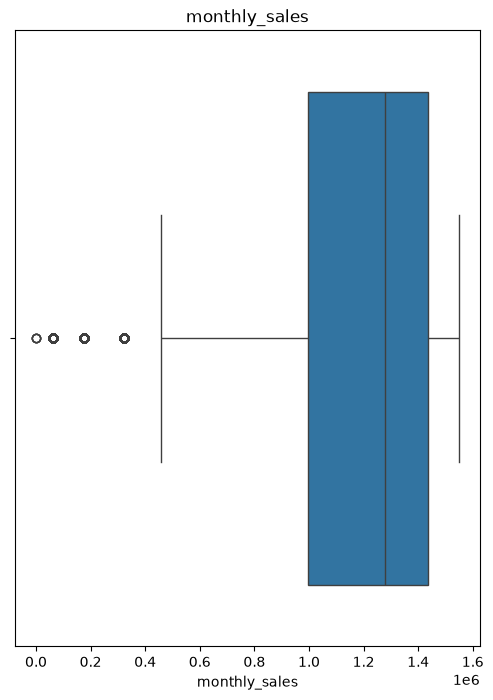

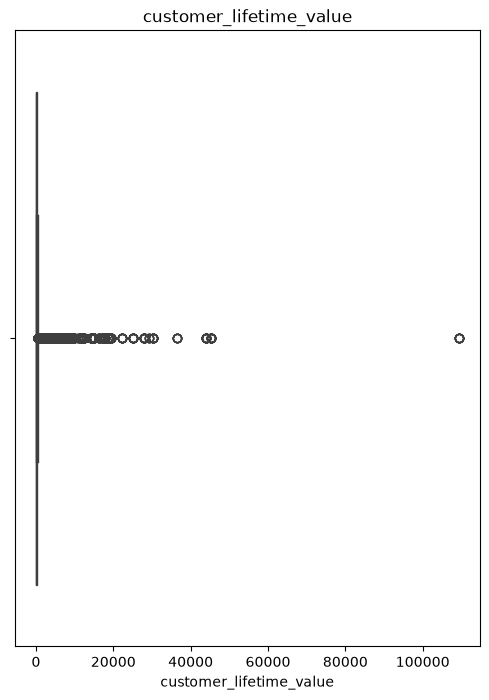

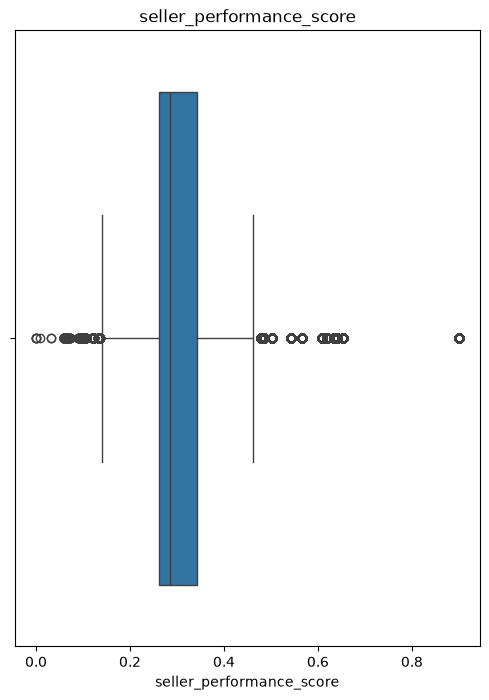

In [44]:
col_lsit = [i for i in df_master.select_dtypes(include=np.number).columns]

for col in col_lsit:
    plt.figure(figsize=(6,8))
    sns.boxplot(data=df_master,x=col)
    plt.title(f"{col}")
    plt.show()

In [45]:
df_master.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'price_capped',
       'freight_value_capped', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'total_payment_value',
       'max_installments', 'primary_payment_type', 'payment_sequential',
       'avg_review_score', 'review_count', 'delivery_time_days',
       'shipping_duration_days', 'order_processing_time_days',
       'tota